# Exercise 1 — Linear Algebra
Solutions with step-by-step explanations. Built collaboratively with an AI assistant (as the assignment encourages).

## Part 1 — Word Embeddings

## Part 2 — Solving a Linear System

We have three linear equations in three unknowns:

$$x_1+x_2+x_3=6,\qquad x_1-x_2+x_3=2,\qquad x_1+x_2-x_3=0.$$

**Matrix form.** Collect the coefficients into a matrix $A$, the unknowns into a column vector $x$, and the right-hand sides into $b$, so the whole system becomes one equation $A\,x = b$:

$$A=\begin{bmatrix}1&1&1\\ 1&-1&1\\ 1&1&-1\end{bmatrix},\quad x=\begin{bmatrix}x_1\\x_2\\x_3\end{bmatrix},\quad b=\begin{bmatrix}6\\2\\0\end{bmatrix}.$$

**Why invertibility matters.** If $A$ is invertible we can multiply both sides by $A^{-1}$ to get $x=A^{-1}b$ — a *unique* solution. $A$ is invertible exactly when its determinant is non-zero.

**A practical note.** Mathematically the answer is $x=A^{-1}b$, but in code we use `np.linalg.solve(A, b)` instead of forming $A^{-1}$ explicitly: it is faster and numerically more stable (it solves the system directly rather than inverting and then multiplying).

In [1]:
import numpy as np

A = np.array([[1, 1, 1],
              [1, -1, 1],
              [1, 1, -1]], dtype=float)
b = np.array([6, 2, 0], dtype=float)

det = np.linalg.det(A)
print("det(A) =", round(det, 6))            # expect 4.0  -> invertible
assert not np.isclose(det, 0), "A is singular!"

x = np.linalg.solve(A, b)
print("x =", x)                             # expect [1. 2. 3.]

# Verify against the hand-derived answer and against the original equations
assert np.allclose(x, [1, 2, 3]), x
assert np.allclose(A @ x, b), "A@x must equal b"
print("Verified: x1=1, x2=2, x3=3")

det(A) = 4.0
x = [1. 2. 3.]
Verified: x1=1, x2=2, x3=3


### Geometric intuition

Each equation describes a **plane** in 3-D space (all points $(x_1,x_2,x_3)$ that satisfy it). Solving the system means finding the point that lies on *all three* planes at once. Because $A$ is invertible (det $\neq 0$), the three planes meet at exactly **one** point — and that point is the solution $(1,2,3)$, marked in red below.

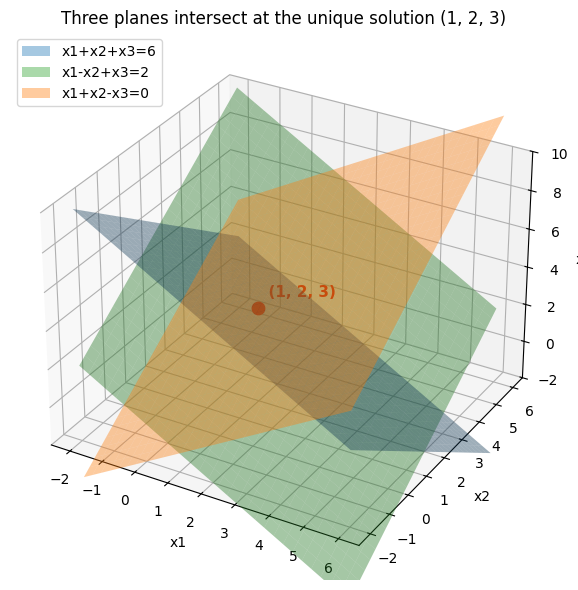

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (enables 3d projection)

# Grid over x1, x2; solve each plane for x3 (z)
g = np.linspace(-2, 6, 30)
X, Y = np.meshgrid(g, g)
Z1 = 6 - X - Y      # x1 + x2 + x3 = 6  -> z = 6 - x - y
Z2 = 2 - X + Y      # x1 - x2 + x3 = 2  -> z = 2 - x + y
Z3 = X + Y          # x1 + x2 - x3 = 0  -> z = x + y

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X, Y, Z1, alpha=0.4, color="tab:blue")
ax.plot_surface(X, Y, Z2, alpha=0.4, color="tab:green")
ax.plot_surface(X, Y, Z3, alpha=0.4, color="tab:orange")

# The unique solution
ax.scatter([1], [2], [3], color="red", s=80, depthshade=False)
ax.text(1, 2, 3.6, "  (1, 2, 3)", color="red", fontsize=11, weight="bold")

ax.set_xlabel("x1"); ax.set_ylabel("x2"); ax.set_zlabel("x3")
ax.set_zlim(-2, 10)
ax.set_title("Three planes intersect at the unique solution (1, 2, 3)")
proxies = [plt.Rectangle((0,0),1,1,fc=c,alpha=0.4) for c in ["tab:blue","tab:green","tab:orange"]]
ax.legend(proxies, ["x1+x2+x3=6", "x1-x2+x3=2", "x1+x2-x3=0"], loc="upper left")
plt.tight_layout()
plt.savefig("fig_part2_planes.png", dpi=110, bbox_inches="tight")
plt.show()

### How the solution is actually computed — Gaussian elimination

`np.linalg.solve` doesn't compute an inverse; under the hood it does **Gaussian elimination**: repeatedly add multiples of one equation to another to peel away variables, until each row tells you one unknown directly.

We work on the **augmented matrix** $[A \mid b]$ — the coefficients with the right-hand side glued on as a last column. The goal is to reach $[I \mid x]$ (identity on the left), at which point the last column *is* the answer. Each panel below is one stage; the label is the row operation applied to get there. Every step is computed in code, so it's exact.

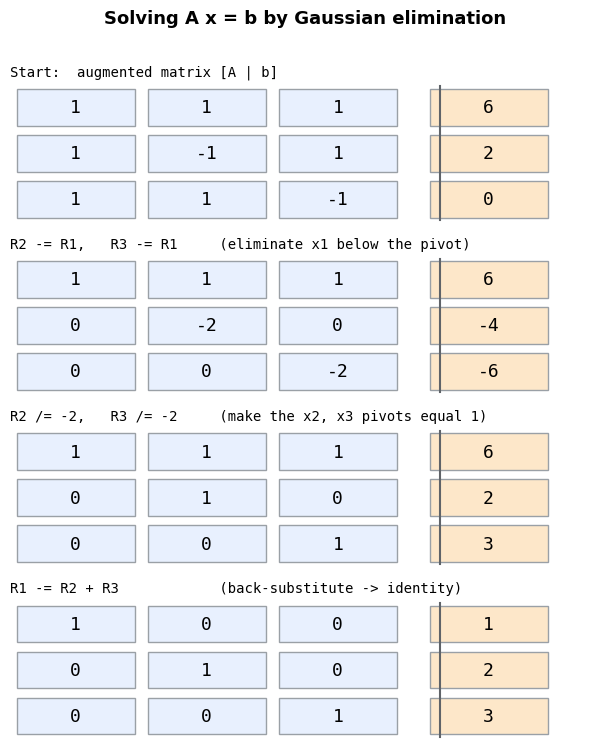

Final solution read off the last column: [1. 2. 3.]


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Perform Gaussian elimination, recording each stage
steps = []
M = np.array([[1, 1, 1, 6],
              [1, -1, 1, 2],
              [1, 1, -1, 0]], dtype=float)
steps.append((M.copy(), "Start:  augmented matrix [A | b]"))

M[1] = M[1] - M[0]; M[2] = M[2] - M[0]      # clear x1 from rows 2 and 3
steps.append((M.copy(), "R2 -= R1,   R3 -= R1     (eliminate x1 below the pivot)"))

M[1] = M[1] / -2; M[2] = M[2] / -2          # normalise pivots to 1
steps.append((M.copy(), "R2 /= -2,   R3 /= -2     (make the x2, x3 pivots equal 1)"))

M[0] = M[0] - M[1] - M[2]                    # back-substitute into row 1
steps.append((M.copy(), "R1 -= R2 + R3            (back-substitute -> identity)"))

assert np.allclose(M[:, :3], np.eye(3))      # left block is now the identity
assert np.allclose(M[:, 3], [1, 2, 3])       # so the last column is the solution

def draw_aug(ax, Mat, title):
    ax.set_xlim(-0.5, 4.0); ax.set_ylim(-0.5, 2.5); ax.invert_yaxis(); ax.axis("off")
    ax.set_title(title, loc="left", fontsize=10, family="monospace")
    for r in range(3):
        for c in range(4):
            val = Mat[r, c]
            txt = f"{val + 0.0:g}"
            if txt == "-0": txt = "0"
            is_b = (c == 3)
            ax.add_patch(plt.Rectangle((c-0.45 + (0.15 if is_b else 0), r-0.4), 0.9, 0.8,
                         fill=True, fc=("#fde7c9" if is_b else "#e8f0fe"), ec="#9aa0a6"))
            ax.text(c + (0.15 if is_b else 0), r, txt, ha="center", va="center",
                    fontsize=13, family="monospace")
    # vertical divider between A and b
    ax.plot([2.78, 2.78], [-0.45, 2.45], color="#5f6368", lw=1.5)

fig, axes = plt.subplots(len(steps), 1, figsize=(6.2, 7.6))
for ax, (Mat, title) in zip(axes, steps):
    draw_aug(ax, Mat, title)
fig.suptitle("Solving A x = b by Gaussian elimination", fontsize=13, weight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("fig_part2_elimination.png", dpi=120, bbox_inches="tight")
plt.show()

print("Final solution read off the last column:", M[:, 3])

### A third route — building the inverse $A^{-1}$ explicitly

Elimination is what `np.linalg.solve` does internally. But it's worth seeing the
*explicit* inverse at least once, because it shows where $A^{-1}$ comes from.

The cofactor formula is

$$A^{-1}=\frac{1}{\det(A)}\,\operatorname{adj}(A),\qquad \operatorname{adj}(A)=C^{\mathsf T},$$

where $C$ is the **cofactor matrix**: $C_{ij}=(-1)^{i+j}M_{ij}$, and the *minor* $M_{ij}$
is the determinant of $A$ after deleting row $i$ and column $j$. The sign pattern
$(-1)^{i+j}$ is the checkerboard $\begin{smallmatrix}+&-&+\\-&+&-\\+&-&+\end{smallmatrix}$.

For our matrix this gives

$$C=\begin{bmatrix}0&2&2\\ 2&-2&0\\ 2&0&-2\end{bmatrix},
\qquad
A^{-1}=\frac{1}{4}\begin{bmatrix}0&2&2\\ 2&-2&0\\ 2&0&-2\end{bmatrix}
=\begin{bmatrix}0&0.5&0.5\\ 0.5&-0.5&0\\ 0.5&0&-0.5\end{bmatrix}.$$

Then $x=A^{-1}b$. Reading the rows: $x_1=0.5(2)=1$, $x_2=0.5(6)-0.5(2)=2$,
$x_3=0.5(6)=3$ — the same $(1,2,3)$ as before.

In [4]:
import numpy as np
np.set_printoptions(suppress=True)

# Build the cofactor matrix from minors (the by-hand recipe, in code)
def minor(M, i, j):
    sub = np.delete(np.delete(M, i, axis=0), j, axis=1)
    return np.linalg.det(sub)

C = np.array([[(-1)**(i + j) * minor(A, i, j) for j in range(3)] for i in range(3)])
adj = C.T                          # adjugate = transpose of cofactor matrix
A_inv = adj / det                  # explicit inverse via the cofactor formula

print("cofactor matrix C =\n", np.round(C, 6))
print("\nA^-1 (explicit, adj/det) =\n", np.round(A_inv, 6))
print("\nMatches np.linalg.inv(A)? ", np.allclose(A_inv, np.linalg.inv(A)))
print("A @ A^-1 = I ? ", np.allclose(A @ A_inv, np.eye(3)))

x_inv = A_inv @ b                  # solve via the explicit inverse
print("\nx = A^-1 @ b =", x_inv)
assert np.allclose(x_inv, [1, 2, 3])
print("Same solution (1,2,3) as elimination / np.linalg.solve. ✓")

cofactor matrix C =
 [[ 0.  2.  2.]
 [ 2. -2. -0.]
 [ 2. -0. -2.]]

A^-1 (explicit, adj/det) =
 [[ 0.   0.5  0.5]
 [ 0.5 -0.5 -0. ]
 [ 0.5 -0.  -0.5]]

Matches np.linalg.inv(A)?  True
A @ A^-1 = I ?  True

x = A^-1 @ b = [1. 2. 3.]
Same solution (1,2,3) as elimination / np.linalg.solve. ✓


**Why we still prefer `np.linalg.solve`.** All three routes — elimination, the
explicit inverse, and `solve` — give the identical $(1,2,3)$. But the explicit inverse
needed **nine** $2\times2$ determinants (one per entry) just for a $3\times3$, and for an
$n\times n$ matrix inverting costs roughly $3\times$ the arithmetic of a single
elimination *and* accumulates more rounding error. You also pay that full cost even
though you only need the answer for one particular $b$. Inverting is the best way to
*understand* the solution; elimination is the best way to *compute* it.

## Part 3 — Linearity of Matrix Multiplication

Matrix multiplication defines a map $L(x)=Ax$. We claim $L$ is **linear**, which means
it satisfies two properties for all vectors $u,v$ and every scalar $c$:

1. **Additivity:** $\;L(u+v)=L(u)+L(v)$
2. **Homogeneity:** $\;L(c\,u)=c\,L(u)$

(Together these are equivalent to the single rule $L(c\,u+d\,v)=c\,L(u)+d\,L(v)$.)

**Proof.** Everything follows from the entry formula $(Ax)_i=\sum_j A_{ij}\,x_j$, because
sums distribute and scalars factor out.

*Additivity*, entry by entry:
$$\big(A(u+v)\big)_i=\sum_j A_{ij}(u_j+v_j)=\sum_j A_{ij}u_j+\sum_j A_{ij}v_j=(Au)_i+(Av)_i.$$
True for every row $i$, so $A(u+v)=Au+Av$.

*Homogeneity*, entry by entry:
$$\big(A(c\,u)\big)_i=\sum_j A_{ij}(c\,u_j)=c\sum_j A_{ij}u_j=c\,(Au)_i,$$
so $A(c\,u)=c\,(Au)$.

The deep point: $Ax$ is built only from multiplication and addition — no squaring, no
added constants, nothing nonlinear — which is exactly *why* it is linear. Below we both
check this numerically and picture it geometrically.

In [5]:
import numpy as np
rng = np.random.default_rng(0)
A3 = rng.integers(-3, 4, size=(3, 3)).astype(float)
u = rng.integers(-3, 4, size=(3, 1)).astype(float)
v = rng.integers(-3, 4, size=(3, 1)).astype(float)
c = 2.5

# Additivity and homogeneity, checked on random data
assert np.allclose(A3 @ (u + v), A3 @ u + A3 @ v), "additivity failed"
assert np.allclose(A3 @ (c * u), c * (A3 @ u)),     "homogeneity failed"
print("A(u+v) - (Au+Av) =", (A3 @ (u + v) - (A3 @ u + A3 @ v)).ravel())  # ~0
print("A(c*u) - c*(Au)  =", (A3 @ (c * u) - c * (A3 @ u)).ravel())       # ~0
print("Additivity and homogeneity both hold numerically. ✓")

A(u+v) - (Au+Av) = [0. 0. 0.]
A(c*u) - c*(Au)  = [0. 0. 0.]
Additivity and homogeneity both hold numerically. ✓


### Geometric intuition — $A$ maps a parallelogram to a parallelogram

Additivity has a clean picture in 2-D. Build $u+v$ by the **parallelogram rule** on the
left; then apply $A$. You land in exactly the same place as applying $A$ to $u$ and $v$
*first* and adding the results on the right. A linear map sends parallelograms to
parallelograms and keeps the origin fixed — it never bends straight lines.

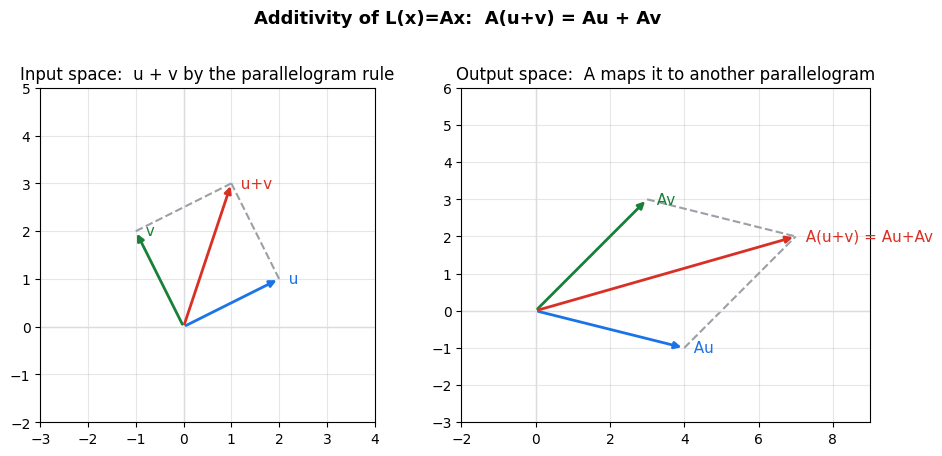

A(u+v) = [7. 2.]  equals  Au+Av = [7. 2.]


In [6]:
import numpy as np
import matplotlib.pyplot as plt

A2 = np.array([[1.0, 2.0],
               [-1.0, 1.0]])        # an invertible 2x2 map
u2 = np.array([2.0, 1.0])
v2 = np.array([-1.0, 2.0])

def arrow(ax, vec, color, label, base=(0, 0)):
    ax.annotate("", xy=(base[0] + vec[0], base[1] + vec[1]), xytext=base,
                arrowprops=dict(arrowstyle="-|>", color=color, lw=2))
    ax.text(base[0] + vec[0], base[1] + vec[1], "  " + label, color=color,
            fontsize=11, va="center")

fig, (axL, axR) = plt.subplots(1, 2, figsize=(10, 4.6))

# ---- input space ----
arrow(axL, u2, "#1a73e8", "u")
arrow(axL, v2, "#188038", "v")
arrow(axL, u2 + v2, "#d93025", "u+v")
# parallelogram edges (dashed): v translated to tip of u, and u translated to tip of v
axL.plot([u2[0], u2[0] + v2[0]], [u2[1], u2[1] + v2[1]], "--", color="#9aa0a6")
axL.plot([v2[0], v2[0] + u2[0]], [v2[1], v2[1] + u2[1]], "--", color="#9aa0a6")
axL.set_title("Input space:  u + v by the parallelogram rule")

# ---- output space ----
Au, Av = A2 @ u2, A2 @ v2
arrow(axR, Au, "#1a73e8", "Au")
arrow(axR, Av, "#188038", "Av")
arrow(axR, Au + Av, "#d93025", "A(u+v) = Au+Av")
axR.plot([Au[0], Au[0] + Av[0]], [Au[1], Au[1] + Av[1]], "--", color="#9aa0a6")
axR.plot([Av[0], Av[0] + Au[0]], [Av[1], Av[1] + Au[1]], "--", color="#9aa0a6")
axR.set_title("Output space:  A maps it to another parallelogram")

for ax in (axL, axR):
    ax.axhline(0, color="#dadce0", lw=1); ax.axvline(0, color="#dadce0", lw=1)
    ax.set_aspect("equal"); ax.grid(True, alpha=0.3)
axL.set_xlim(-3, 4); axL.set_ylim(-2, 5)        # input vectors are small
axR.set_xlim(-2, 9); axR.set_ylim(-3, 6)        # output reaches (7,2); leave room

# confirm the red arrows really coincide
assert np.allclose(A2 @ (u2 + v2), Au + Av)
fig.suptitle("Additivity of L(x)=Ax:  A(u+v) = Au + Av", fontsize=13, weight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("fig_part3_linearity.png", dpi=120, bbox_inches="tight")
plt.show()
print("A(u+v) =", A2 @ (u2 + v2), " equals  Au+Av =", Au + Av)

## Part 4 — The Polynomial Derivative Matrix

We represent a polynomial of degree $\le 4$ by its **coefficient vector** in the basis
$\{1,x,x^2,x^3,x^4\}$:

$$q(x)=a_0+a_1x+a_2x^2+a_3x^3+a_4x^4\;\longleftrightarrow\;
p=\begin{bmatrix}a_0\\a_1\\a_2\\a_3\\a_4\end{bmatrix}.$$

Differentiation is **linear**, so it is some matrix $D$. To build it, apply $\frac{d}{dx}$
to each basis vector: $x^k\mapsto k\,x^{k-1}$. So column $k$ pushes weight $k$ up into
row $k-1$ — the superdiagonal entries $1,2,3,4$:

$$D=\begin{bmatrix}0&1&0&0&0\\0&0&2&0&0\\0&0&0&3&0\\0&0&0&0&4\\0&0&0&0&0\end{bmatrix}.$$

A product is **"kosher"** (well-defined) only when the inner dimensions match: an
$(m\times n)$ matrix times an $(n\times p)$ matrix. We check each of the five products
below against a hand-derived value with an `assert`.

In [7]:
import numpy as np

# Derivative matrix on polynomials of degree <= 4, basis {1, x, x^2, x^3, x^4}
D = np.array([[0, 1, 0, 0, 0],
              [0, 0, 2, 0, 0],
              [0, 0, 0, 3, 0],
              [0, 0, 0, 0, 4],
              [0, 0, 0, 0, 0]], dtype=float)
p = np.ones((5, 1))                  # 5x1 column of ones  ->  q(x)=1+x+x^2+x^3+x^4

# 1) D @ p : (5x5)(5x1) = 5x1  -> kosher.  Coeffs of q'(x).
r1 = D @ p
print("1) D @ p   =", r1.ravel())     # [1 2 3 4 0]
assert np.allclose(r1.ravel(), [1, 2, 3, 4, 0])

# 2) p.T @ D : (1x5)(5x5) = 1x5  -> kosher.  Column sums of D.
r2 = p.T @ D
print("2) p.T @ D =", r2.ravel())     # [0 1 2 3 4]
assert np.allclose(r2.ravel(), [0, 1, 2, 3, 4])

# 3) D @ D = D^2 : (5x5)(5x5) -> kosher.  The second-derivative matrix.
r3 = D @ D
expected_D2 = np.array([[0, 0, 2, 0, 0],
                        [0, 0, 0, 6, 0],
                        [0, 0, 0, 0, 12],
                        [0, 0, 0, 0, 0],
                        [0, 0, 0, 0, 0]], dtype=float)
print("3) D @ D   =\n", r3)
assert np.allclose(r3, expected_D2)

# 4) p.T @ D @ p : (1x5)(5x5)(5x1) = scalar -> kosher.
r4 = (p.T @ D @ p).item()
print("4) p.T @ D @ p =", r4)         # 10.0
assert np.isclose(r4, 10)

# 5) General n: p^T D p = sum_{k=1}^{n-1} k = n(n-1)/2
def deriv_matrix(n):
    Dn = np.zeros((n, n))
    for k in range(1, n):
        Dn[k - 1, k] = k
    return Dn

for n in [2, 3, 5, 8]:
    Dn, pn = deriv_matrix(n), np.ones((n, 1))
    val = (pn.T @ Dn @ pn).item()
    assert np.isclose(val, n * (n - 1) / 2), (n, val)
print("5) General: p^T D p = n(n-1)/2  (verified for n = 2, 3, 5, 8)")

1) D @ p   = [1. 2. 3. 4. 0.]
2) p.T @ D = [0. 1. 2. 3. 4.]
3) D @ D   =
 [[ 0.  0.  2.  0.  0.]
 [ 0.  0.  0.  6.  0.]
 [ 0.  0.  0.  0. 12.]
 [ 0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.]]
4) p.T @ D @ p = 10.0
5) General: p^T D p = n(n-1)/2  (verified for n = 2, 3, 5, 8)


**Reading the results.** With $q(x)=1+x+x^2+x^3+x^4$ (all coefficients $1$):

- $Dp=(1,2,3,4,0)$ are exactly the coefficients of $q'(x)=1+2x+3x^2+4x^3$.
- $p^{\mathsf T}Dp = q'(1) = 1+2+3+4 = 10$ — equivalently, the sum of all entries of $D$.
- For a general $n$, the entries are $1,2,\dots,n-1$, so
  $p^{\mathsf T}Dp=\sum_{k=1}^{n-1}k=\dfrac{n(n-1)}{2}$, the $(n-1)$-th triangular number.

The figure below plots $q$ against its derivative $q'=Dp$ so you can see the matrix really
is "differentiation in coordinates".

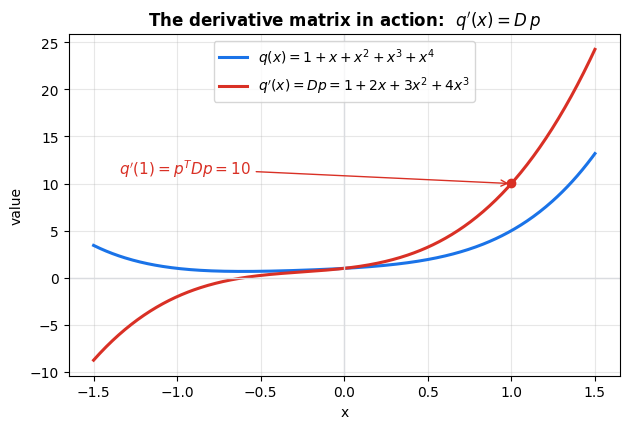

Check: q'(1) = 10.0  = p^T D p


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Coefficient vectors -> evaluate the polynomials they represent
q_coeffs  = p.ravel()            # q(x) = 1 + x + x^2 + x^3 + x^4
qp_coeffs = (D @ p).ravel()      # q'(x) = 1 + 2x + 3x^2 + 4x^3  (from D @ p)

def poly_eval(coeffs, xs):
    powers = np.vstack([xs**k for k in range(len(coeffs))])   # rows: x^0..x^4
    return coeffs @ powers

xs = np.linspace(-1.5, 1.5, 400)
q_vals  = poly_eval(q_coeffs, xs)
qp_vals = poly_eval(qp_coeffs, xs)

fig, ax = plt.subplots(figsize=(6.4, 4.4))
ax.plot(xs, q_vals,  color="#1a73e8", lw=2.2, label=r"$q(x)=1+x+x^2+x^3+x^4$")
ax.plot(xs, qp_vals, color="#d93025", lw=2.2, label=r"$q'(x)=Dp=1+2x+3x^2+4x^3$")
ax.axhline(0, color="#dadce0", lw=1); ax.axvline(0, color="#dadce0", lw=1)

# Mark the slope check: q'(1) = p^T D p = 10
ax.plot([1], [qp_vals[np.argmin(abs(xs - 1))]], "o", color="#d93025")
ax.annotate(r"$q'(1)=p^{T}Dp=10$", xy=(1, 10), xytext=(-1.35, 11),
            fontsize=11, color="#d93025",
            arrowprops=dict(arrowstyle="->", color="#d93025"))

ax.set_title("The derivative matrix in action:  $q'(x)=D\\,p$", weight="bold")
ax.set_xlabel("x"); ax.set_ylabel("value"); ax.legend(loc="upper center")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("fig_part4_derivative.png", dpi=120, bbox_inches="tight")
plt.show()

# Sanity: q'(1) should equal p^T D p = 10
assert np.isclose(poly_eval(qp_coeffs, np.array([1.0]))[0], 10)
print("Check: q'(1) =", poly_eval(qp_coeffs, np.array([1.0]))[0], " = p^T D p")